In [1]:
import torch
import torchvision

print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

torch version: 2.10.0+cu130
torchvision version: 0.25.0+cu130


In [2]:
import torch
import torchvision

from torch import nn
from torchvision import transforms

try:
    from torchinfo import summary
    import matplotlib.pyplot as plt
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo matplotlib

    from torchinfo import summary
    import matplotlib.pyplot as plt

In [3]:
from going_modular.going_modular import data_setup, engine

try:
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    print("install....")
    !pip install -q requests

    from helper_functions import download_data, set_seeds, plot_loss_curves


C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
from pathlib import Path

origin_path = "data/pizza_steak_sushi"

image_path = Path(origin_path)

image_path


WindowsPath('data/pizza_steak_sushi')

In [9]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

In [10]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [11]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x165bd7a7a10>,
 ['pizza', 'steak', 'sushi'])

In [15]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(0))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

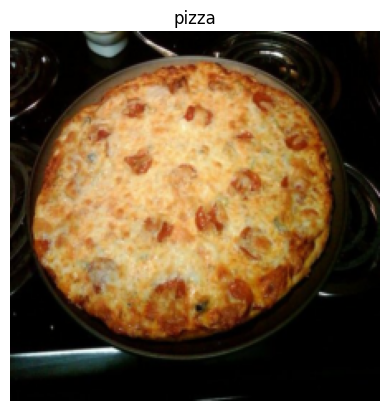

In [16]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False)

In [17]:
# from gemini

class GeminiPatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=16, embed_dim=768):
        super().__init__()
        self.patch_size = patch_size

        # ใช้ Convolution ในการหั่นภาพและแปลงเป็น Embedding ในขั้นตอนเดียว
        # stride=patch_size ทำให้ Filter กระโดดไปทีละช่อง ไม่ซ้อนทับกัน (Non-overlapping)
        self.projection = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        # เลเยอร์สำหรับคลี่ภาพจาก 2D เป็น 1D (Flatten)
        self.flatten = nn.Flatten(start_dim=2)

    def forward(self, x):
        # x shape: (batch, channels, height, width)
        x = self.projection(x) # (batch, embed_dim, H/P, W/P)
        x = self.flatten(x)    # (batch, embed_dim, N_patches)
        x = x.transpose(1, 2)  # (batch, N_patches, embed_dim) -> พร้อมเข้า Transformer
        return x

In [18]:
# from gemini

class ViTEmbeddings(nn.Module):
    def __init__(self, img_size=224, patch_size=16, embed_dim=768):
        super().__init__()
        self.patch_embed = GeminiPatchEmbedding(patch_size=patch_size, embed_dim=embed_dim)
        num_patches = (img_size // patch_size) ** 2

        # สร้าง Class Token: [1, 1, embed_dim]
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # สร้าง Position Embedding: [1, num_patches + 1, embed_dim]
        # +1 เพราะต้องเผื่อที่ให้ Class Token ด้วย
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))

    def forward(self, x):
        batch_size = x.shape[0]
        x = self.patch_embed(x) # (batch, n_patches, embed_dim)

        # ขยาย cls_token ให้เท่ากับขนาด batch แล้วนำไปต่อหน้า x
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) # (batch, n_patches + 1, embed_dim)

        # บวก Position Embedding ตามสมการ (1)
        x = x + self.pos_embed
        return x

In [19]:
# from gemini

gemini_Embeddings = ViTEmbeddings(img_size=224, patch_size=16, embed_dim=768)

x = image.unsqueeze(0)

gemini_patch_and_position_embedding = gemini_Embeddings(x)

gemini_patch_and_position_embedding.shape, x.shape


(torch.Size([1, 197, 768]), torch.Size([1, 3, 224, 224]))

In [26]:
# from gemini

class GeminiViT(nn.Module):
    def __init__(self,
                 img_size=224,
                 patch_size=16,
                 in_channels=3,
                 num_classes=1000,
                 embed_dim=768,
                 depth=12,
                 num_heads=12,
                 mlp_dim=3072,
                 dropout=0.1):
        super().__init__()

        # --- ส่วนประกอบของสมการที่ (1) ---
        self.patch_size = patch_size
        num_patches = (img_size // patch_size) ** 2

        # Patch Projection (E ในสมการ)
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

        # Class Token (x_class)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # Position Embedding (E_pos)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)

        # --- ส่วนประกอบของสมการที่ (2) และ (3) ---
        # ใช้ TransformerEncoderLayer โดยตั้งค่า norm_first=True เพื่อให้ตรงกับสมการ
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True # สำคัญมาก: ทำ LN ก่อน MSA และ MLP
        )

        # วนซ้ำชั้น Encoder ทั้งหมด L ชั้น (Depth)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # --- ส่วนประกอบของสมการที่ (4) ---
        self.ln = nn.LayerNorm(embed_dim)
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # สมการ (1): เตรียมข้อมูล Input
        # 1. หั่น Patch และทำ Linear Projection
        x = self.patch_embed(x) # (batch, embed_dim, H/P, W/P)
        x = x.flatten(2).transpose(1, 2) # (batch, num_patches, embed_dim)

        # 2. เพิ่ม Class Token ไว้หน้าสุด
        batch_size = x.shape[0]
        cls_token = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_token, x), dim=1) # (batch, num_patches + 1, embed_dim)

        # 3. บวก Position Embedding
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # สมการ (2) และ (3): ผ่าน Transformer Encoder (L รอบ)
        x = self.transformer_encoder(x)

        # สมการ (4): ดึง Class Token ออกมาสรุปผล
        # x_L^0 คือตำแหน่งที่ 0 ของ Sequence ลำดับที่ L
        cls_token_final = x[:, 0]
        y = self.mlp_head(self.ln(cls_token_final))

        return y

In [27]:
# Example of creating the class embedding and expanding over a batch dimension
batch_size = 32
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768)) # create a single learnable class token
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1) # expand the single learnable class token across the batch dimension, "-1" means to "infer the dimension"

# Print out the change in shapes
print(f"Shape of class token embedding single: {class_token_embedding_single.shape}")
print(f"Shape of class token embedding expanded: {class_token_embedding_expanded.shape}")

Shape of class token embedding single: torch.Size([1, 1, 768])
Shape of class token embedding expanded: torch.Size([32, 1, 768])


In [28]:
class_names

['pizza', 'steak', 'sushi']

In [29]:
set_seeds()

# Create a random tensor with same shape as a single image
random_image_tensor = torch.randn(1, 3, 224, 224)

# Create an instance of ViT with the number of classes we're working with (pizza, steak, sushi)
gemini_vit = GeminiViT(num_classes=len(class_names))

# Pass the random image tensor to our ViT instance
gemini_vit(random_image_tensor)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_71360\3759269461.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)


tensor([[-0.1439,  0.2023,  0.2064]], grad_fn=<AddmmBackward0>)

In [30]:
# gemini

summary(model=gemini_vit,
         input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
         # col_names=["input_size"], # uncomment for smaller output
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"]
  )

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
GeminiViT (GeminiViT)                                   [32, 3, 224, 224]    [32, 3]              152,064              True
├─Conv2d (patch_embed)                                  [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
├─Dropout (pos_drop)                                    [32, 197, 768]       [32, 197, 768]       --                   --
├─TransformerEncoder (transformer_encoder)              [32, 197, 768]       [32, 197, 768]       --                   True
│    └─ModuleList (layers)                              --                   --                   --                   True
│    │    └─TransformerEncoderLayer (0)                 [32, 197, 768]       [32, 197, 768]       7,087,872            True
│    │    └─TransformerEncoderLayer (1)                 [32, 197, 768]       [32, 197, 768]       7,087,872            True
│    

In [31]:
# gemini

gemini_optimizer = torch.optim.Adam(params=gemini_vit.parameters(),
                             lr=3e-3, 
                             betas=(0.9, 0.999), 
                             weight_decay=0.1) 

loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()

gemini_results = engine.train(model=gemini_vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=gemini_optimizer,
                       loss_fn=loss_fn,
                       epochs=10,
                       device=device)

  0%|          | 0/10 [00:38<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 68716) exited unexpectedly